In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from Training.emotion_dataset import EmotionDataset
from Models.multimodal_model import MultimodalEmotionModel

In [2]:
fusion_df = pd.read_csv(
    "../Outputs/multimodal_features.csv"
)

fusion_df.head()

,file,emotion,mean_pitch,max_pitch,min_pitch,std_pitch,pitch_range,mean_loudness,max_loudness,min_loudness,...,hubert_758,hubert_759,hubert_760,hubert_761,hubert_762,hubert_763,hubert_764,hubert_765,hubert_766,hubert_767
0,03-01-01-01-01-01-01.wav,neutral,-1.281334,-1.313478,-0.910337,-1.054649,-1.035071,-0.640215,-0.600914,-0.359370,...,0.347639,1.086390,-2.226975,0.044137,0.581057,-0.837176,0.560290,0.628094,-1.777968,0.267199
1,03-01-01-01-01-02-01.wav,neutral,-1.217456,-1.273545,-0.843626,-1.033650,-1.019688,-0.627634,-0.594691,-0.334576,...,-0.780705,-0.301101,-2.897990,0.288971,0.332221,-0.848459,0.161824,0.057598,-1.919760,0.099796
2,03-01-01-01-02-01-01.wav,neutral,-1.275647,-1.389712,-0.801280,-1.126794,-1.161858,-0.597392,-0.528325,-0.322795,...,-2.011175,-0.833556,-3.200465,1.987318,-0.201903,-0.254995,0.180600,0.179949,-2.263536,0.052155
3,03-01-01-01-02-02-01.wav,neutral,-1.289378,-1.391529,-0.835187,-1.109301,-1.149837,-0.612257,-0.522755,-0.334468,...,-1.121960,-0.710967,-1.485014,1.496337,-0.021844,-0.771523,-0.620534,0.607375,-0.987329,0.381298
4,03-01-02-01-01-01-01.wav,calm,-1.209688,-1.316103,-0.859423,-0.989294,-1.058871,-0.686882,-0.622439,-0.350728,...,-0.265490,-0.183614,-2.196150,-0.037556,-0.084948,-0.751670,0.824286,-0.245938,-1.212850,-0.762560


In [3]:
print(fusion_df.shape)

(2880, 804)


In [4]:
fusion_df["emotion"].value_counts()

emotion
calm         384
happy        384
sad          384
angry        384
fearful      384
disgust      384
surprised    384
neutral      192
Name: count, dtype: int64

In [5]:
label_encoder = LabelEncoder()

fusion_df["emotion"] = label_encoder.fit_transform(
    fusion_df["emotion"]
)

fusion_df.head()
joblib.dump(
    label_encoder,
    "../Models/label_encoder.pkl"
)

print("Label Encoder Saved")

Label Encoder Saved


In [6]:
for emotion, label in zip(

    label_encoder.classes_,

    range(len(label_encoder.classes_))

):

    print(

        emotion,

        "→",

        label

    )

angry → 0
calm → 1
disgust → 2
fearful → 3
happy → 4
neutral → 5
sad → 6
surprised → 7


In [7]:
print(fusion_df.shape)

psycho_features = fusion_df.iloc[:, 2:36].values
hubert_features = fusion_df.iloc[:, 36:].values
labels = fusion_df["emotion"].values

print("Psycho:", psycho_features.shape)
print("HuBERT:", hubert_features.shape)
print("Labels:", labels.shape)

(2880, 804)
Psycho: (2880, 34)
HuBERT: (2880, 768)
Labels: (2880,)


In [8]:
X_psy_train, X_psy_test, \
X_hubert_train, X_hubert_test, \
y_train, y_test = train_test_split(

    psycho_features,

    hubert_features,

    labels,

    test_size=0.2,

    random_state=42,

    stratify=labels

)

In [9]:
print(X_psy_train.shape)
print(X_psy_test.shape)

print(X_hubert_train.shape)
print(X_hubert_test.shape)

print(y_train.shape)
print(y_test.shape)

(2304, 34)
(576, 34)
(2304, 768)
(576, 768)
(2304,)
(576,)


In [10]:
train_dataset = EmotionDataset(

    X_psy_train,

    X_hubert_train,

    y_train

)

test_dataset = EmotionDataset(

    X_psy_test,

    X_hubert_test,

    y_test

)

In [11]:
print(len(train_dataset))
print(len(test_dataset))

2304
576


In [12]:
psycho, hubert, label = train_dataset[0]

print(psycho.shape)
print(hubert.shape)
print(label)

torch.Size([34])
torch.Size([768])
tensor(3)


In [13]:
train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False

)

In [14]:
psycho_batch, hubert_batch, labels_batch = next(
    iter(train_loader)
)

print(psycho_batch.shape)

print(hubert_batch.shape)

print(labels_batch.shape)

torch.Size([32, 34])
torch.Size([32, 768])
torch.Size([32])


In [15]:
print(labels_batch)

tensor([7, 3, 1, 6, 2, 6, 2, 2, 2, 2, 3, 2, 7, 0, 1, 0, 2, 0, 1, 7, 4, 7, 2, 0,
        0, 3, 3, 4, 1, 3, 0, 5])


In [16]:
model = MultimodalEmotionModel(

    psycho_dim=34,

    hubert_dim=768,

    hidden_dim=128,

    num_classes=8

)

print(model)

MultimodalEmotionModel(
  (psycho_encoder): Linear(in_features=34, out_features=128, bias=True)
  (hubert_encoder): Linear(in_features=768, out_features=128, bias=True)
  (cross_attention): CrossAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=8, bias=True)
)


In [17]:
psycho_batch, hubert_batch, labels_batch = next(
    iter(train_loader)
)

print(psycho_batch.shape)
print(hubert_batch.shape)
print(labels_batch.shape)

torch.Size([32, 34])
torch.Size([32, 768])
torch.Size([32])


In [18]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

print(device)

cuda


In [19]:
model = model.to(device)

psycho_batch = psycho_batch.to(device)

hubert_batch = hubert_batch.to(device)

labels_batch = labels_batch.to(device)

In [20]:
logits, embedding, attention = model(

    psycho_batch,

    hubert_batch

)

In [21]:
print("Logits :", logits.shape)

print("Attention :", attention.shape)

Logits : torch.Size([32, 8])
Attention : torch.Size([32, 1, 1])


In [22]:
predictions = torch.argmax(

    logits,

    dim=1

)

print(predictions)

tensor([2, 2, 0, 1, 3, 0, 0, 5, 7, 4, 0, 3, 5, 5, 5, 2, 0, 5, 2, 0, 4, 0, 4, 5,
        5, 5, 0, 0, 4, 7, 6, 4], device='cuda:0')


In [23]:
print("Prediction")

print(predictions)

print()

print("Ground Truth")

print(labels_batch)

Prediction
tensor([2, 2, 0, 1, 3, 0, 0, 5, 7, 4, 0, 3, 5, 5, 5, 2, 0, 5, 2, 0, 4, 0, 4, 5,
        5, 5, 0, 0, 4, 7, 6, 4], device='cuda:0')

Ground Truth
tensor([4, 4, 1, 6, 3, 1, 7, 5, 3, 3, 3, 2, 1, 0, 6, 0, 0, 7, 1, 2, 4, 2, 2, 3,
        2, 0, 7, 1, 3, 1, 0, 5], device='cuda:0')


In [24]:
criterion = torch.nn.CrossEntropyLoss()

In [25]:
loss = criterion(

    logits,

    labels_batch

)

print(loss.item())

2.1284384727478027


In [26]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

In [27]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for psycho_batch, hubert_batch, labels_batch in dataloader:

        psycho_batch = psycho_batch.to(device)

        hubert_batch = hubert_batch.to(device)

        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        logits, embedding, attention = model(

            psycho_batch,

            hubert_batch

        )

        loss = criterion(

            logits,

            labels_batch

        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(

            logits,

            dim=1

        )

        correct += (

            predictions == labels_batch

        ).sum().item()

        total += labels_batch.size(0)

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [28]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for psycho_batch, hubert_batch, labels_batch in dataloader:

            psycho_batch = psycho_batch.to(device)

            hubert_batch = hubert_batch.to(device)

            labels_batch = labels_batch.to(device)

            logits, embedding, attention = model(

                psycho_batch,

                hubert_batch

            )

            loss = criterion(

                logits,

                labels_batch

            )

            running_loss += loss.item()

            predictions = torch.argmax(

                logits,

                dim=1

            )

            correct += (

                predictions == labels_batch

            ).sum().item()

            total += labels_batch.size(0)

    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [29]:
train_losses = []

train_accuracies = []

val_losses = []

val_accuracies = []

best_accuracy = 0.0

In [30]:
num_epochs = 20

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        device

    )

    val_loss, val_accuracy = validate(

        model,

        test_loader,

        criterion,

        device

    )

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)

    val_accuracies.append(val_accuracy)

    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    print(f"Train Loss        : {train_loss:.4f}")

    print(f"Train Accuracy    : {train_accuracy:.4f}")

    print(f"Validation Loss   : {val_loss:.4f}")

    print(f"Validation Accuracy : {val_accuracy:.4f}")

    if val_accuracy > best_accuracy:

        best_accuracy = val_accuracy

        torch.save(

            model.state_dict(),

            "../Models/best_model.pth"

        )

        print("✅ Best Model Saved")


Epoch [1/20]
Train Loss        : 1.0921
Train Accuracy    : 0.6146
Validation Loss   : 0.6620
Validation Accuracy : 0.7743
✅ Best Model Saved

Epoch [2/20]
Train Loss        : 0.5132
Train Accuracy    : 0.8190
Validation Loss   : 0.5126
Validation Accuracy : 0.8160
✅ Best Model Saved

Epoch [3/20]
Train Loss        : 0.3519
Train Accuracy    : 0.8754
Validation Loss   : 0.5066
Validation Accuracy : 0.8125

Epoch [4/20]
Train Loss        : 0.2976
Train Accuracy    : 0.8971
Validation Loss   : 0.3983
Validation Accuracy : 0.8681
✅ Best Model Saved

Epoch [5/20]
Train Loss        : 0.2104
Train Accuracy    : 0.9227
Validation Loss   : 0.4390
Validation Accuracy : 0.8802
✅ Best Model Saved

Epoch [6/20]
Train Loss        : 0.1700
Train Accuracy    : 0.9384
Validation Loss   : 0.3076
Validation Accuracy : 0.8993
✅ Best Model Saved

Epoch [7/20]
Train Loss        : 0.1372
Train Accuracy    : 0.9510
Validation Loss   : 0.3601
Validation Accuracy : 0.9097
✅ Best Model Saved

Epoch [8/20]
Trai

In [31]:
print("Best Validation Accuracy :", best_accuracy)

Best Validation Accuracy : 0.9496527777777778


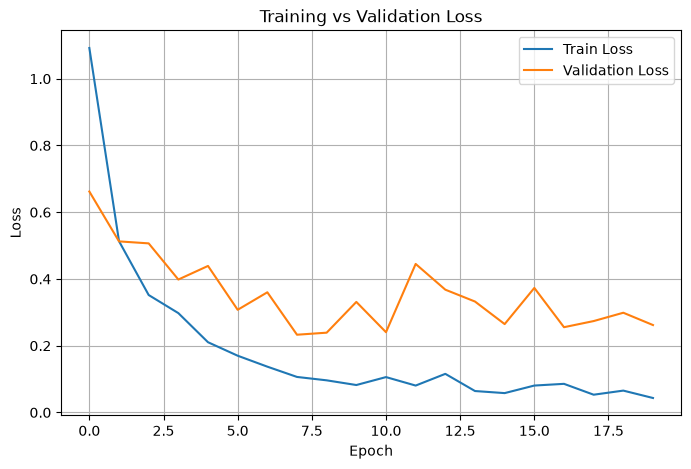

In [32]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

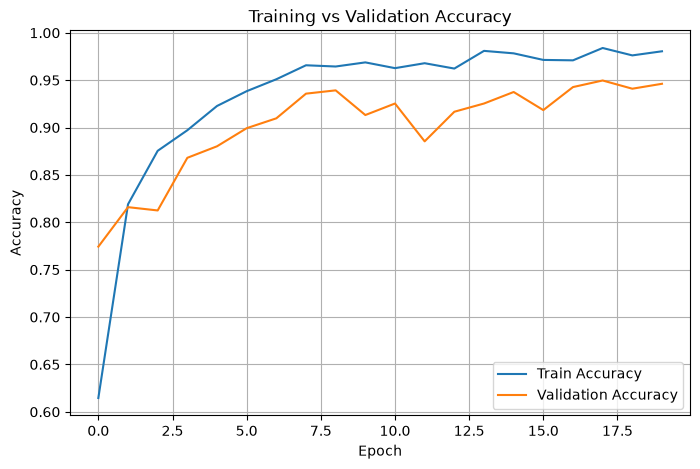

In [33]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")

plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()